# Optimal control investigations

In [24]:
import matplotlib.pyplot as plt
import matplotlib.cm as colormaps
import pickle
import numpy as np
import os
import sys

import neurolib.dashboard.data as data
import neurolib.dashboard.functions as functions
import neurolib.dashboard.layout as layout
from neurolib.models.aln import ALNModel

### Mapping of bistable regime

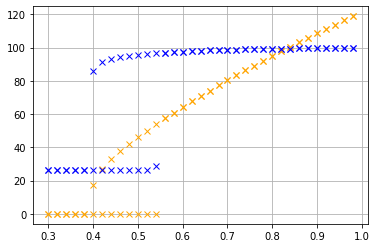

In [25]:
aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

readpath = '.' + os.sep + 'data' + os.sep + '00000'

with open(readpath + os.sep + 'bi.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc = load_array[0]
ext_inh = load_array[1]

grid_resolution = layout.grid_resolution

aln.params.ext_inh_current = 0.5 * 5.

for i in np.arange(0.3,1,0.02):    
    aln.params.ext_exc_current = i * 5.

    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)

    up_ = np.zeros((2))
    up_[0] = aln.rates_exc[0,-1] 
    up_[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)

    down_ = np.zeros((2))
    down_[0] = aln.rates_exc[0,-1] 
    down_[1] = aln.rates_inh[0,-1]
    
    plt.plot(i, up_[0], "x", color="orange")
    plt.plot(i, up_[1], "x", color="blue")
    plt.plot(i, down_[0], "x", color="orange")
    plt.plot(i, down_[1], "x", color="blue")
    
plt.show()

- no need to go "beyond" boundary horizontally, as rate is above target rate

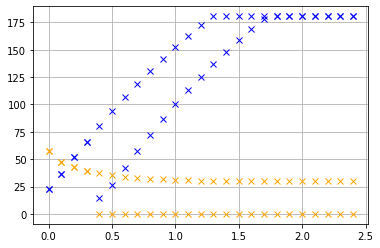

In [26]:
aln.params.ext_exc_current = 0.45 * 5.

for i in np.arange(0.,2.5,0.1):    
    aln.params.ext_inh_current = i * 5.

    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)

    up_ = np.zeros((2))
    up_[0] = aln.rates_exc[0,-1] 
    up_[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)

    down_ = np.zeros((2))
    down_[0] = aln.rates_exc[0,-1] 
    down_[1] = aln.rates_inh[0,-1]
    
    plt.plot(i, up_[0], "x", color="orange")
    plt.plot(i, up_[1], "x", color="blue")
    plt.plot(i, down_[0], "x", color="orange")
    plt.plot(i, down_[1], "x", color="blue")
    
plt.show()

- rate "beyond" boundary is increasing when going downwards vertically, no need to go beyond boundary

In [27]:
dt = aln.params.dt
up_rates = np.zeros((len(ext_exc), 2))
down_rates = np.zeros((len(ext_exc), 2))
diff_rates = np.zeros((len(ext_exc), 2))

dist_up_regime = np.zeros((len(ext_exc), 2))
dist_attractor_rate = np.zeros((len(ext_exc), 2))

for i in range(len(ext_exc)):
    print(i, len(ext_exc))
    dist_up_regime[i,0] = data.dist_right(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)
    dist_up_regime[i,1] = data.dist_low(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)
    
    aln.params.ext_exc_current = ext_exc[i] * 5.
    aln.params.ext_inh_current = ext_inh[i] * 5.

    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)

    up_ = np.zeros((2))
    up_[0] = aln.rates_exc[0,-1] 
    up_[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = - 3.)
    aln.run(control=control0)

    down_ = np.zeros((2))
    down_[0] = aln.rates_exc[0,-1] 
    down_[1] = aln.rates_inh[0,-1]
    
    up_rates[i,:] = up_
    down_rates[i,:] = down_
    diff_rates[i,:] = up_ - down_
    
    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]
                
    aln.params.duration = 300.
    
    data.setinit(aln, init_state_vars)
    attr = True
    while attr:
        aln.params['rates_exc_init'] += 1.
        aln.run(control=aln.getZeroControl())
        if np.abs(aln.rates_exc[0,-1] - down_rates[i,0]) > 1.:
            #print("No longer in low attractor for init exc rate = ", aln.params['rates_exc_init'])
            dist_attractor_rate[i,0] = aln.params['rates_exc_init'] - init_state_vars[0]
            #plt.plot(np.arange(0, aln.params.duration + dt, dt), aln.rates_exc[0,:], color="red")
            attr = False
    
    data.setinit(aln, init_state_vars)
    attr = True
    while attr:
        aln.params['rates_inh_init'] += 1.
        aln.run(control=aln.getZeroControl())
        if np.abs(aln.rates_inh[0,-1] - down_rates[i,1]) > 1.:
            #print("No longer in low attractor for init inh rate = ", aln.params['rates_inh_init'])
            dist_attractor_rate[i,1] = aln.params['rates_inh_init'] - init_state_vars[1]
            #plt.plot(np.arange(0, aln.params.duration + dt, dt), aln.rates_inh[0,:], color="blue")
            #plt.show()
            attr = False

0 152
1 152
2 152
3 152
4 152
5 152
6 152
7 152
8 152
9 152
10 152
11 152
12 152
13 152
14 152
15 152
16 152
17 152
18 152
19 152
20 152
21 152
22 152
23 152
24 152
25 152
26 152
27 152
28 152
29 152
30 152
31 152
32 152
33 152
34 152
35 152
36 152
37 152
38 152
39 152
40 152
41 152
42 152
43 152
44 152
45 152
46 152
47 152
48 152
49 152
50 152
51 152
52 152
53 152
54 152
55 152
56 152
57 152
58 152
59 152
60 152
61 152
62 152
63 152
64 152
65 152
66 152
67 152
68 152
69 152
70 152
71 152
72 152
73 152
74 152
75 152
76 152
77 152
78 152
79 152
80 152
81 152
82 152
83 152
84 152
85 152
86 152
87 152
88 152
89 152
90 152
91 152
92 152
93 152
94 152
95 152
96 152
97 152
98 152
99 152
100 152
101 152
102 152
103 152
104 152
105 152
106 152
107 152
108 152
109 152
110 152
111 152
112 152
113 152
114 152
115 152
116 152
117 152
118 152
119 152
120 152
121 152
122 152
123 152
124 152
125 152
126 152
127 152
128 152
129 152
130 152
131 152
132 152
133 152
134 152
135 152
136 152
137 152
138 15

In [28]:
up_rates_norm = np.zeros((len(ext_exc), 2))
up_rates_norm[:,0] = ( up_rates[:,0] - np.amin(up_rates[:,0]) ) / ( np.amax(up_rates[:,0]) - np.amin(up_rates[:,0]) )
up_rates_norm[:,1] = ( up_rates[:,1] - np.amin(up_rates[:,1]) ) / ( np.amax(up_rates[:,1]) - np.amin(up_rates[:,1]) )

down_rates_norm = np.zeros((len(ext_exc), 2))
down_rates_norm[:,0] = ( down_rates[:,0] - np.amin(down_rates[:,0]) ) / ( np.amax(down_rates[:,0]) - np.amin(down_rates[:,0]) )
down_rates_norm[:,1] = ( down_rates[:,1] - np.amin(down_rates[:,1]) ) / ( np.amax(down_rates[:,1]) - np.amin(down_rates[:,1]) )

diff_rates_norm = np.zeros((len(ext_exc), 2))
diff_rates_norm[:,0] = ( diff_rates[:,0] - np.amin(diff_rates[:,0]) ) / ( np.amax(diff_rates[:,0]) - np.amin(diff_rates[:,0]) )
diff_rates_norm[:,1] = ( diff_rates[:,1] - np.amin(diff_rates[:,1]) ) / ( np.amax(diff_rates[:,1]) - np.amin(diff_rates[:,1]) )

dist_attractor_rate_norm = np.zeros((len(ext_exc), 2))
d_e_max = 0.
d_e_min = 1000.
for i in range(len(ext_exc)):
    if (down_rates[i,0] + dist_attractor_rate[i,0]) < 180. and dist_attractor_rate[i,0] > d_e_max:
        d_e_max = dist_attractor_rate[i,0].copy()
    if (down_rates[i,0] + dist_attractor_rate[i,0]) < 180. and dist_attractor_rate[i,0] < d_e_min:
        d_e_min = dist_attractor_rate[i,0].copy()
dist_attractor_rate_norm[:,0] = ( dist_attractor_rate[:,0] - d_e_min ) / ( d_e_max - d_e_min )

### Rates of high and low state

AttributeError: 'AxesSubplot' object has no attribute 'set_legend'

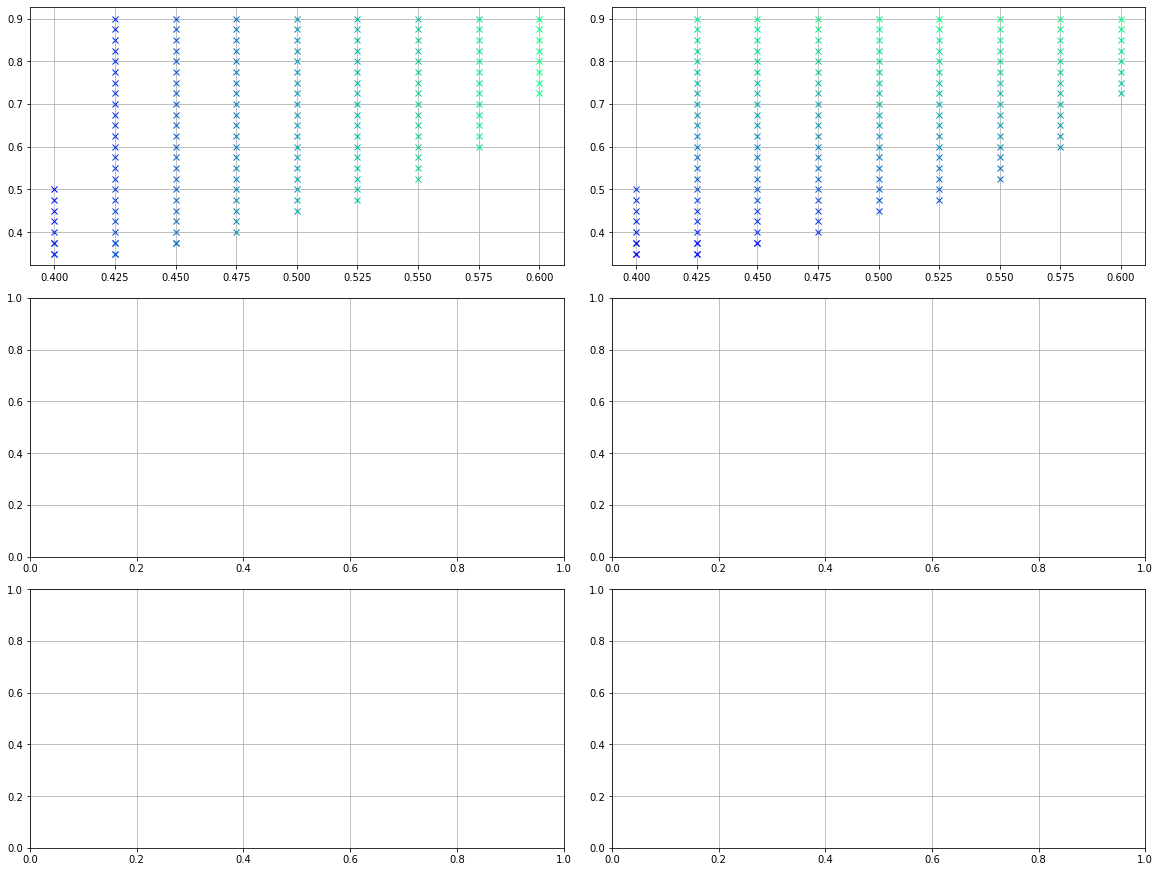

In [29]:
cmap = colormaps.get_cmap('winter')

fig0, ax = plt.subplots(3, 2, constrained_layout=True, figsize = (16,12) )

for i in range(len(ext_exc)):
    ax[0,0].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(up_rates_norm[i,0]), label='normalized high rates')
    ax[0,1].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(up_rates_norm[i,1]), label='normalized high rates')
    
ax[0,0,].set_legend()
sx[0,1].set_legend()
 
ax[0,0].set_xlabel('Ext exc current')
ax[0,1].set_xlabel('Ext exc current')
ax[0,0].set_ylabel('Ext inh current')
ax[0,1].set_ylabel('Ext inh current')

ax[1,0].plot(ext_exc, up_rates[:,0], 'x')
ax[1,1].plot(ext_exc, up_rates[:,1], 'x')
ax[1,0].set_xlabel('Ext exc current')
ax[1,1].set_xlabel('Ext exc current')
ax[1,0].set_ylabel('High exc rate')
ax[1,1].set_ylabel('High inh rate')
ax[2,0].plot(ext_inh, up_rates[:,0], 'x')
ax[2,1].plot(ext_inh, up_rates[:,1], 'x')
ax[2,0].set_xlabel('Ext inh current')
ax[2,1].set_xlabel('Ext inh current')
ax[2,0].set_ylabel('High exc rate')
ax[2,1].set_ylabel('High inh rate')

cols = ['Exc rates', 'Inh rates']
pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

plt.show()

- excitatory high rates are mainly determined by depend on external excitatory current
- inhibitory high rates are mainly determined by depend on external inhibitory current

In [ ]:
fig1, ax = plt.subplots(3, 2, constrained_layout=True, figsize = (16,12) )

for i in range(len(ext_exc)):
    ax[0,0].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(down_rates_norm[i,0]))
    ax[0,1].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(down_rates_norm[i,1]))
 
ax[0,0].set_xlabel('Ext exc current')
ax[0,1].set_xlabel('Ext exc current')
ax[0,0].set_ylabel('Ext inh current')
ax[0,1].set_ylabel('Ext inh current')

ax[1,0].plot(ext_exc, down_rates[:,0], 'x')
ax[1,1].plot(ext_exc, down_rates[:,1], 'x')
ax[1,0].set_xlabel('Ext exc current')
ax[1,1].set_xlabel('Ext exc current')
ax[1,0].set_ylabel('Low exc rate')
ax[1,1].set_ylabel('Low inh rate')
ax[2,0].plot(ext_inh, down_rates[:,0], 'x')
ax[2,1].plot(ext_inh, down_rates[:,1], 'x')
ax[2,0].set_xlabel('Ext inh current')
ax[2,1].set_xlabel('Ext inh current')
ax[2,0].set_ylabel('Low exc rate')
ax[2,1].set_ylabel('Low inh rate')

cols = ['Exc rates', 'Inh rates']
pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

plt.show()

- excitatory low rates are close to zero in all cases
- inhibitory low rates are mainly determined by depend on external inhibitory current
- distance between high and low inhibitory rates slightly decreases with higher external inhibitory currents

In [ ]:
fig2, ax = plt.subplots(4, 4, constrained_layout=True, figsize = (12,12) )
ax[0,0].plot(down_rates[:,0], down_rates[:,0], 'x')
ax[0,0].set_xlabel('low rates exc')
ax[0,0].set_ylabel('low rates exc')

ax[1,0].plot(up_rates[:,0], down_rates[:,0], 'x')
ax[1,0].set_xlabel('high rates exc')
ax[1,0].set_ylabel('low rates exc')

ax[1,1].plot(up_rates[:,0], up_rates[:,0], 'x')
ax[1,1].set_xlabel('high rates exc')
ax[1,1].set_ylabel('high rates exc')

ax[2,0].plot(down_rates[:,1], down_rates[:,0], 'x')
ax[2,0].set_xlabel('low rates inh')
ax[2,0].set_ylabel('low rates exc')

ax[2,1].plot(down_rates[:,1], up_rates[:,0], 'x')
ax[2,1].set_xlabel('low rates inh')
ax[2,1].set_ylabel('high rates exc')

ax[2,2].plot(down_rates[:,1], down_rates[:,1], 'x')
ax[2,2].set_xlabel('low rates inh')
ax[2,2].set_ylabel('low rates inh')

ax[3,0].plot(up_rates[:,1], down_rates[:,0], 'x')
ax[3,0].set_xlabel('high rates inh')
ax[3,0].set_ylabel('low rates exc')

ax[3,1].plot(up_rates[:,1], up_rates[:,0], 'x')
ax[3,1].set_xlabel('high rates inh')
ax[3,1].set_ylabel('high rates exc')

ax[3,2].plot(up_rates[:,1], down_rates[:,1], 'x')
ax[3,2].set_xlabel('high rates inh')
ax[3,2].set_ylabel('low rates inh')

ax[3,3].plot(up_rates[:,1], up_rates[:,1], 'x')
ax[3,3].set_xlabel('high rates inh')
ax[3,3].set_ylabel('high rates inh')

plt.show()

- high and low inhibitory rates are strongly correlated

### Differences between up and down states in rates

In [ ]:
cmap = colormaps.get_cmap('winter')
fig2, ax = plt.subplots(3, 2, constrained_layout=True, figsize = (16,12) )

for i in range(len(ext_exc)):
    ax[0,0].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(diff_rates_norm[i,0]))
    ax[0,1].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(diff_rates_norm[i,1]))
 
ax[0,0].set_xlabel('Ext exc current')
ax[0,1].set_xlabel('Ext exc current')
ax[0,0].set_ylabel('Ext inh current')
ax[0,1].set_ylabel('Ext inh current')

ax[1,0].plot(ext_exc, diff_rates[:,0], 'x')
ax[1,1].plot(ext_exc, diff_rates[:,1], 'x')
ax[1,0].set_xlabel('Ext exc current')
ax[1,1].set_xlabel('Ext exc current')
ax[1,0].set_ylabel('Diff exc rate')
ax[1,1].set_ylabel('Diff inh rate')
ax[2,0].plot(ext_inh, diff_rates[:,0], 'x')
ax[2,1].plot(ext_inh, diff_rates[:,1], 'x')
ax[2,0].set_xlabel('Ext inh current')
ax[2,1].set_xlabel('Ext inh current')
ax[2,0].set_ylabel('Diff exc rate')
ax[2,1].set_ylabel('Diff inh rate')

cols = ['Exc rates', 'Inh rates']
pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

plt.show()

plt.plot(diff_rates[:,0], diff_rates[:,1], 'x')
plt.xlabel('difference in exc rate')
plt.ylabel('difference in inh rate')
plt.show()

- external excitatory current determines the difference in the excitatory rate between up and down state
- external inhibitory current determines the difference in the inhibitory rate between up and down state except for the low region close to the oscillatory regime

### Dependence of difference in rates on distance to regime boundary

In [ ]:
cmap = colormaps.get_cmap('Blues')
fig3, ax = plt.subplots(2, 2, constrained_layout=True, figsize = (16,12) )

for i in range(len(ext_exc)):
    ax[0,0].plot(dist_up_regime[i,0], diff_rates[i,0], 'x', color=cmap(0.99))
    ax[0,1].plot(dist_up_regime[i,0], diff_rates[i,1], 'x', color=cmap(0.99))
    ax[1,0].plot(dist_up_regime[i,1], diff_rates[i,0], 'x', color=cmap(0.99))
    ax[1,1].plot(dist_up_regime[i,1], diff_rates[i,1], 'x', color=cmap(0.99))
        
ax[0,0].set_xlabel('distance to up regime in exc current')
ax[0,0].set_ylabel('difference in exc rate')
ax[0,1].set_xlabel('distance to up regime in exc current')
ax[0,1].set_ylabel('difference in inh rate')
ax[1,0].set_xlabel('distance to up regime in inh current')
ax[1,0].set_ylabel('difference in exc rate')
ax[1,1].set_xlabel('distance to up regime in inh current')
ax[1,1].set_ylabel('difference in inh rate')

plt.show()

- high horizontal distance only works for low external excitatory current
- high vertical distance only works for high external inhibitory currents, where gap between high and low state decreases

### Dependence of distance to attractor in rate on distance to regime boundary and on difference in rates

In [ ]:
cmap = colormaps.get_cmap('Blues')
fig3, ax = plt.subplots(2, 2, constrained_layout=True, figsize = (16,12) )

for i in range(len(ext_exc)):
    if dist_attractor_rate_norm[i,0] <= 1.:
        ax[0,0].plot(dist_up_regime[i,0], dist_attractor_rate[i,0], 'x', color=cmap(0.99))
        ax[0,1].plot(diff_rates[i,0], dist_attractor_rate[i,0], 'x', color=cmap(0.99))
        ax[1,0].plot(dist_up_regime[i,1], dist_attractor_rate[i,0], 'x', color=cmap(0.99))
        ax[1,1].plot(diff_rates[i,1], dist_attractor_rate[i,0], 'x', color=cmap(0.99))
    else:
        ax[0,0].plot(dist_up_regime[i,0], 180., 'x', color='red')
        ax[0,1].plot(diff_rates[i,0], 180., 'x', color='red')
        ax[1,0].plot(dist_up_regime[i,1], 180., 'x', color='red')
        ax[1,1].plot(diff_rates[i,1], 180., 'x', color='red')
        
ax[0,0].set_xlabel('distance to up regime in exc current')
ax[0,0].set_ylabel('distance to attractor in exc rate')
ax[0,1].set_xlabel('difference in exc rates up/down')
ax[0,1].set_ylabel('distance to attractor in exc rate')
ax[1,0].set_xlabel('distance to up regime in inh current')
ax[1,0].set_ylabel('distance to attractor in exc rate')
ax[1,1].set_xlabel('difference in inh rates up/down')
ax[1,1].set_ylabel('distance to attractor in exc rate')
plt.show()

What determines if and at which rate we are attracted towards the up state?
- slight tendency to higher rates at higher distance in current space
- slight tendency to higher rates ar lower difference in rate space

$\rightarrow$ "distance to attractor" is nothing to easily work with

### maximum amplitude as a function of difference in rates

In [ ]:
fig1, ax = plt.subplots(2, 3, constrained_layout=True, figsize = (16,8) )

readcase_rates('00000')

ax[0,0].plot(d_x, lenx_1, 'o', color="red", markersize=4, label='Max control current exc')
ax[0,0].plot(d_y, np.abs(leny_2), 'o', color="blue", markersize=4, label='Max control current inh')
ax[0,1].plot(d_x, cost_s_x, 'x', color="red", markersize=6, label="sparsity cost")
ax[0,1].plot(d_y, cost_s_y, 'x', color="blue", markersize=6)
ax[0,1].plot(d_x, cost_e_x, '+', color="red", markersize=6, label="energy cost")
ax[0,1].plot(d_y, cost_e_y, '+', color="blue", markersize=6)
ax[0,2].plot(d_x, cost_p_x, 's', color="red", markersize=6, label='precision cost')
ax[0,2].plot(d_y, cost_p_y, 's', color="blue", markersize=6)

readcase_rates('00001')

ax[0,0].plot(d_x, lenx_1, 'o', color="red", markersize=4)
ax[0,0].plot(d_y, np.abs(leny_2), 'o', color="blue", markersize=4)
ax[0,1].plot(d_x, cost_s_x, 'x', color="red", markersize=6)
ax[0,1].plot(d_y, cost_s_y, 'x', color="blue", markersize=6)
ax[0,1].plot(d_x, cost_e_x, '+', color="red", markersize=6)
ax[0,1].plot(d_y, cost_e_y, '+', color="blue", markersize=6)
ax[0,2].plot(d_x, cost_p_x, 's', color="red", markersize=6)
ax[0,2].plot(d_y, cost_p_y, 's', color="blue", markersize=6)

readcase_rates('10000')

ax[1,0].plot(d_x, np.abs(lenx_1), 'o', color="red", markersize=4, label='Max control current exc')
ax[1,0].plot(d_y, np.abs(leny_2), 'o', color="blue", markersize=4, label='Max control current inh')
ax[1,1].plot(d_x, cost_s_x, 'x', color="red", markersize=6, label="sparsity cost exc")
ax[1,1].plot(d_y, cost_s_y, 'x', color="blue", markersize=6, label="sparsity cost inh")
ax[1,1].plot(d_x, cost_e_x, '+', color="red", markersize=6, label="energy cost exc")
ax[1,1].plot(d_y, cost_e_y, '+', color="blue", markersize=6, label="energy cost inh")
ax[1,2].plot(d_x, cost_p_x, 's', color="red", markersize=6)
ax[1,2].plot(d_y, cost_p_y, 's', color="blue", markersize=6)

ax[0,0].legend()
ax[0,1].legend()
ax[0,2].legend()

cols = ['Maximum control current', 'Sparsity and energy cost', 'Precision cost']
rows = [r'low $\rightarrow$ high', r'high $\rightarrow$ low']

pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax_, row in zip(ax[:,0], rows):
    ax_.annotate(row, xy=(0, 0.5), xytext=(-ax_.yaxis.labelpad - pad, 0),
                xycoords=ax_.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')

ax[1,0].set_xlabel("Difference in rates up/ down")
ax[1,1].set_xlabel("Difference in rates up/ down")
ax[1,2].set_xlabel("Difference in rates up/ down")
ax[0,0].set_ylabel("Max abs amplitude exc/ inh control current [nA]")
ax[1,0].set_ylabel("Max abs amplitude exc/ inh control current [nA]")
ax[0,0].legend()
ax[0,1].legend()
ax[0,2].legend()

cols = ['Maximum control current', 'Sparsity and energy cost', 'Precision cost']
rows = [r'low $\rightarrow$ high', r'high $\rightarrow$ low']

pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax_, row in zip(ax[:,0], rows):
    ax_.annotate(row, xy=(0, 0.5), xytext=(-ax_.yaxis.labelpad - pad, 0),
                xycoords=ax_.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')


plt.show()

- the smaller the rate difference, the larger the amplitude and the sparsity/ energy cost
- the higher the rate difference, the larger the precision cost

### Maximum amplitude as a function of distance to regime boundary

In [ ]:
x_range = np.arange(0, 0.201, 0.01)
fig1, ax = plt.subplots(2, 3, constrained_layout=True, figsize = (16,8) )

readcase('00000')

ax[0,0].plot(d_x, lenx_1, 'o', color="red", markersize=4, label='Max control current exc')
ax[0,0].plot(d_y, np.abs(leny_2), 'o', color="blue", markersize=4, label='Max control current inh')
ax[0,1].plot(d_x, cost_s_x, 'x', color="red", markersize=6, label="sparsity cost")
ax[0,1].plot(d_y, cost_s_y, 'x', color="blue", markersize=6)
ax[0,1].plot(d_x, cost_e_x, '+', color="red", markersize=6, label="energy cost")
ax[0,1].plot(d_y, cost_e_y, '+', color="blue", markersize=6)
ax[0,2].plot(d_x, cost_p_x, 's', color="red", markersize=6, label='precision cost')
ax[0,2].plot(d_y, cost_p_y, 's', color="blue", markersize=6)

readcase('00001')

ax[0,0].plot(d_x, lenx_1, 'o', color="red", markersize=4)
ax[0,0].plot(d_y, np.abs(leny_2), 'o', color="blue", markersize=4)
ax[0,1].plot(d_x, cost_s_x, 'x', color="red", markersize=6)
ax[0,1].plot(d_y, cost_s_y, 'x', color="blue", markersize=6)
ax[0,1].plot(d_x, cost_e_x, '+', color="red", markersize=6)
ax[0,1].plot(d_y, cost_e_y, '+', color="blue", markersize=6)
ax[0,2].plot(d_x, cost_p_x, 's', color="red", markersize=6)
ax[0,2].plot(d_y, cost_p_y, 's', color="blue", markersize=6)

readcase('10000')

ax[1,0].plot(d_x, np.abs(lenx_1), 'o', color="red", markersize=4, label='Max control current exc')
ax[1,0].plot(d_y, np.abs(leny_2), 'o', color="blue", markersize=4, label='Max control current inh')
ax[1,1].plot(d_x, cost_s_x, 'x', color="red", markersize=6, label="sparsity cost exc")
ax[1,1].plot(d_y, cost_s_y, 'x', color="blue", markersize=6, label="sparsity cost inh")
ax[1,1].plot(d_x, cost_e_x, '+', color="red", markersize=6, label="energy cost exc")
ax[1,1].plot(d_y, cost_e_y, '+', color="blue", markersize=6, label="energy cost inh")
ax[1,2].plot(d_x, cost_p_x, 's', color="red", markersize=6)
ax[1,2].plot(d_y, cost_p_y, 's', color="blue", markersize=6)

'''
readcase('10001') # identical solutions as 10000

ax[1,0].plot(d_x, np.abs(lenx_1), 'o', color="red", markersize=4)
ax[1,0].plot(d_y, np.abs(leny_2), 'o', color="blue", markersize=4)
ax[1,1].plot(d_x, cost_s_x, 'x', color="red", markersize=6)
ax[1,1].plot(d_y, cost_s_y, 'x', color="blue", markersize=6)
ax[1,1].plot(d_x, cost_e_x, '+', color="red", markersize=6)
ax[1,1].plot(d_y, cost_e_y, '+', color="blue", markersize=6)
ax[1,2].plot(d_x, cost_p_x, 's', color="red", markersize=6)
ax[1,2].plot(d_y, cost_p_y, 's', color="blue", markersize=6)
'''

ax[0,0].plot(x_range, x_range, color='grey')
ax[1,0].plot(x_range, x_range, color='grey')
ax[1,0].set_xlabel("Horizontal/ vertical distance to up regime [nA]")
ax[1,1].set_xlabel("Horizontal/ vertical distance to up regime [nA]")
ax[0,0].set_xlim((x_range[0], x_range[-1]))
ax[0,0].set_ylabel("Max abs amplitude exc/ inh control current [nA]")
ax[1,0].set_ylabel("Max abs amplitude exc/ inh control current [nA]")
ax[0,0].legend()
ax[0,1].legend()
ax[0,2].legend()

cols = ['Maximum control current', 'Sparsity and energy cost', 'Precision cost']
rows = [r'low $\rightarrow$ high', r'high $\rightarrow$ low']

pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax_, row in zip(ax[:,0], rows):
    ax_.annotate(row, xy=(0, 0.5), xytext=(-ax_.yaxis.labelpad - pad, 0),
                xycoords=ax_.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')


plt.show()


- amplitude scales linearly with distance to boundary of bistable regime
- energy and sparsity cost scales (linearly?) with distance to boundary
- large gap between initial and target state (in both nodes?) $\rightarrow$ high precision cost

In [ ]:
def readcase(case_):
    
    global exc_, inh_, no_c_, both_c_
    global exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2
    global exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4
    global d_x, d_y, cost_p_x, cost_p_y, cost_s_x, cost_e_x, cost_s_y, cost_e_y
    
    readpath = '.' + os.sep + 'data' + os.sep + str(case_) + os.sep

    data_array = data.read_data(readpath, case_)
    exc_, inh_, both_c_, no_c_ = data_array[0:4]
    exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2 = data_array[4:12]
    exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4 = data_array[12:]

    control_data = data.read_control(readpath, case_)
    opt_control = control_data[2]
    opt_cost = control_data[3]
    
    d_x = []
    d_y = []
    
    if case_[0] == '0':
        for i in range(len(exc_1)):
            d_x.append(data.dist_right(exc_1[i], inh_1[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_2)):
            d_y.append(data.dist_low(exc_2[i], inh_2[i], ext_exc, ext_inh, grid_resolution))
    else:
        for i in range(len(exc_1)):
            d_x.append(data.dist_left(exc_1[i], inh_1[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_2)):
            d_y.append(data.dist_up(exc_2[i], inh_2[i], ext_exc, ext_inh, grid_resolution))
        
    cost_p_x = []
    cost_p_y = []
    cost_s_x = []
    cost_e_x = []
    cost_s_y = []
    cost_e_y = []

    for i in range(len(d_x)):
        cost_p_x.append(cost1[i][0][0][0])
        cost_s_x.append(cost1[i][1][0][0])
        cost_e_x.append(cost1[i][2][0][0])
    for i in range(len(d_y)):
        cost_p_y.append(cost2[i][0][0][1])
        cost_s_y.append(cost2[i][1][0][1])
        cost_e_y.append(cost2[i][2][0][1])
        
def readcase_rates(case_):
    
    global exc_, inh_, no_c_, both_c_
    global exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2
    global exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4
    global d_x, d_y, cost_p_x, cost_p_y, cost_s_x, cost_e_x, cost_s_y, cost_e_y
    
    readpath = '.' + os.sep + 'data' + os.sep + str(case_) + os.sep

    data_array = data.read_data(readpath, case_)
    exc_, inh_, both_c_, no_c_ = data_array[0:4]
    exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2 = data_array[4:12]
    exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4 = data_array[12:]

    control_data = data.read_control(readpath, case_)
    opt_control = control_data[2]
    opt_cost = control_data[3]
    
    d_x = []
    d_y = []

    for i in exc_:
        d_x.append(diff_rates[i,0])
    for i in inh_:
        d_y.append(diff_rates[i,1])
        
    cost_p_x = []
    cost_p_y = []
    cost_s_x = []
    cost_e_x = []
    cost_s_y = []
    cost_e_y = []

    for i in range(len(d_x)):
        cost_p_x.append(cost1[i][0][0][0])
        cost_s_x.append(cost1[i][1][0][0])
        cost_e_x.append(cost1[i][2][0][0])
    for i in range(len(d_y)):
        cost_p_y.append(cost2[i][0][0][1])
        cost_s_y.append(cost2[i][1][0][1])
        cost_e_y.append(cost2[i][2][0][1])

### Optimal vs "intuitive" control

In [54]:
13.5-5.9

7.6

### limit maximum amplitude to X% of current maximum value